# Exploratory Data Analysis (EDA) on Processed Data
This notebook explores the cleaned and split dataset to understand class distributions, stratification, and text statistics. This is crucial before moving to model training.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})


## 1. Load Data
We load the train, validation, and test sets from `data/processed/`.

In [2]:
data_dir = '../data/processed'
train_df = pd.read_csv(f"{data_dir}/train.csv")
val_df = pd.read_csv(f"{data_dir}/val.csv")
test_df = pd.read_csv(f"{data_dir}/test.csv")

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")


Train size: 1590
Validation size: 341
Test size: 341


## 2. Check Stratification (FR vs NFR)
We need to ensure that the ratio of FR to NFR is consistent across all three splits.

C:\Users\ThinkPad X1\AppData\Local\Temp\ipykernel_16820\2680379460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Set2")
C:\Users\ThinkPad X1\AppData\Local\Temp\ipykernel_16820\2680379460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Set2")
C:\Users\ThinkPad X1\AppData\Local\Temp\ipykernel_16820\2680379460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Set2")


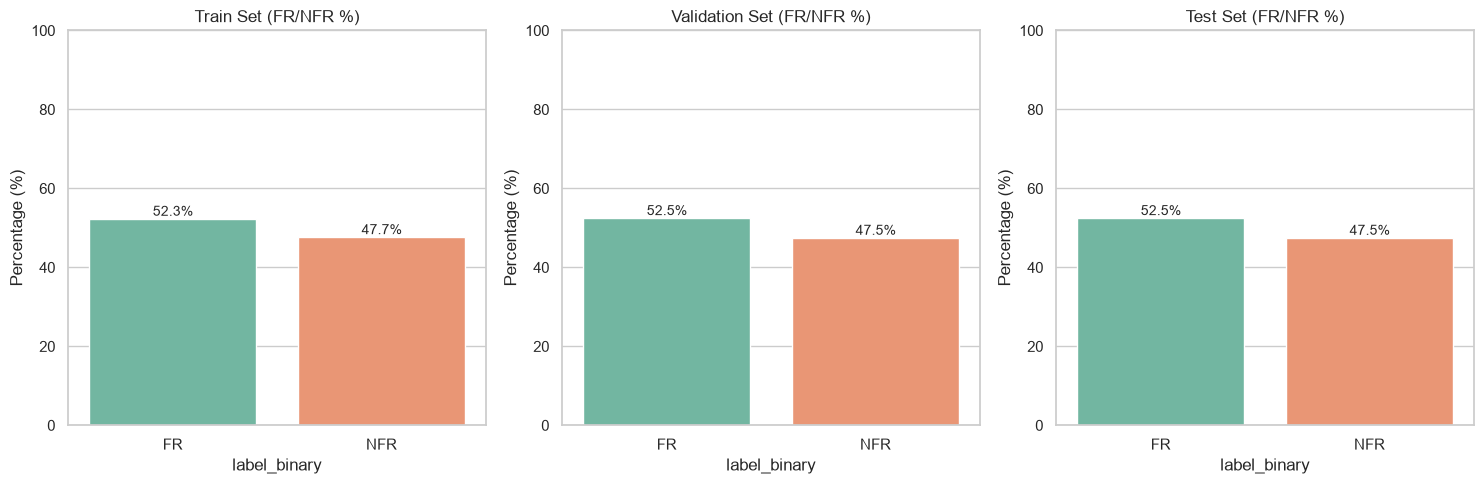

In [3]:
def plot_binary_distribution(dfs, titles):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, df, title in zip(axes, dfs, titles):
        counts = df['label_binary'].value_counts(normalize=True) * 100
        sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Set2")
        ax.set_title(f"{title} (FR/NFR %)")
        ax.set_ylabel("Percentage (%)")
        ax.set_ylim(0, 100)
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

plot_binary_distribution([train_df, val_df, test_df], ['Train Set', 'Validation Set', 'Test Set'])


## 3. Distribution of NFR Subcategories
Let's look at the distribution of the `sub_NFR` categories within the Train set.

C:\Users\ThinkPad X1\AppData\Local\Temp\ipykernel_16820\564151723.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=nfr_only, y='sub_NFR', order=order, palette="viridis")


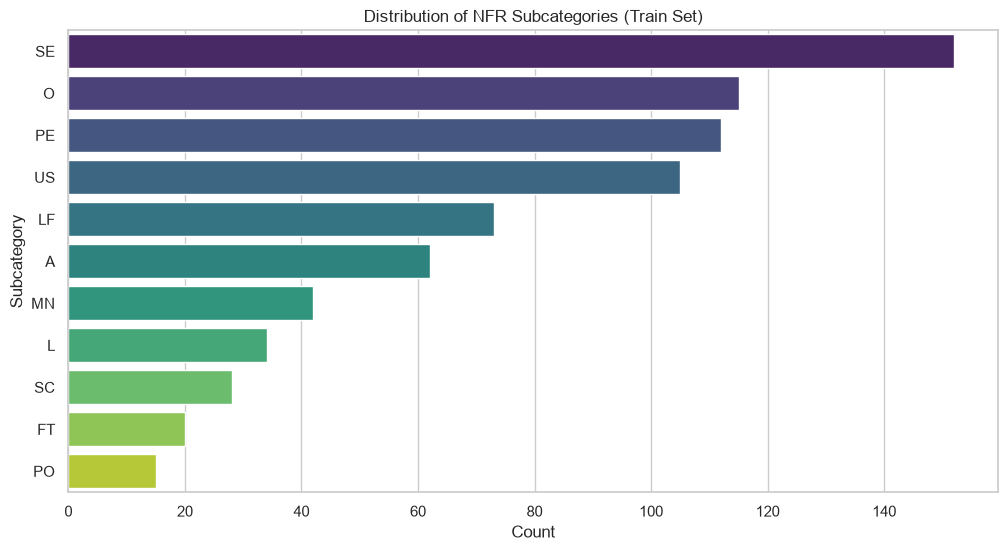

In [4]:
plt.figure(figsize=(12, 6))
nfr_only = train_df[train_df['label_binary'] == 'NFR']
order = nfr_only['sub_NFR'].value_counts().index
sns.countplot(data=nfr_only, y='sub_NFR', order=order, palette="viridis")
plt.title("Distribution of NFR Subcategories (Train Set)")
plt.xlabel("Count")
plt.ylabel("Subcategory")
plt.show()


## 4. Text Length Analysis
Understanding the length of the requirements helps in setting the `max_length` parameter for BERT/ELECTRA models.

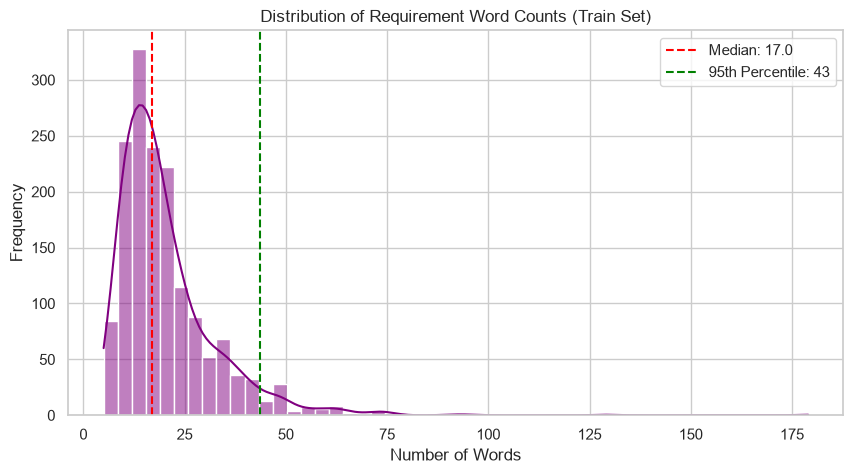

In [5]:
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(train_df['word_count'], bins=50, kde=True, color='purple')
plt.title("Distribution of Requirement Word Counts (Train Set)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.axvline(train_df['word_count'].median(), color='red', linestyle='--', label=f"Median: {train_df['word_count'].median()}")
plt.axvline(train_df['word_count'].quantile(0.95), color='green', linestyle='--', label=f"95th Percentile: {int(train_df['word_count'].quantile(0.95))}")
plt.legend()
plt.show()


In [6]:
print("Word Count Statistics (Train Set):")
print(train_df['word_count'].describe())


Word Count Statistics (Train Set):
count    1590.000000
mean       20.437107
std        12.560870
min         5.000000
25%        12.000000
50%        17.000000
75%        24.000000
max       179.000000
Name: word_count, dtype: float64
